# Dow Theory — a quantitative teardown 🔬
### Latched Industrials/Transports confirmation regime · active-spread HAC *t* · a cash-drag-stripped content test · a matched-persistence random-regime placebo · cost & lookback robustness · a 34-year index check · a synthetic planted-edge power control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![I/T confirmation: Busted](https://img.shields.io/badge/I%2FT_confirmation%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). Dow Theory is partly subjective, so we steelman it into the **tightest mechanical rule a proponent would accept** and ask three separate questions: does timing on the confirmation **beat buy-and-hold** (active-spread HAC *t*), does the confirmation flag carry **forward information** once you strip the cash-drag (content test), and is any of it **distinguishable from a random cash rule** (placebo)? The answers are no, no, and no.

> ⚠️ **Data note.** Industrials = **DIA**, Transports = **IYT** (auto-adjusted ≈ total return), 2004→2026; robustness on **^DJI/^DJT** price-only back to 1992. Cash earns 0, so every Sharpe race is excess-of-cash on both sides. Offline core + synthetic control are deterministic. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from dow_theory import data, strategy as st

ASOF = "2026-05-31"
HAVE_REAL = data.have_real()
if HAVE_REAL:
    DF = data.load_real()
    DF = DF[DF.index <= ASOF]
else:
    DF = None
print("real Dow-Theory cache present:", HAVE_REAL,
      "| days:", (0 if DF is None else len(DF)),
      "| fingerprint:", ("--" if DF is None else data.fingerprint(DF)))

# frozen headline numbers (mirror of docs/results.md)
R = {'asof': '2026-05-31', 'start': '2004-01-02', 'end': '2026-05-29', 'years': 22.4, 'n_days': 5637, 'fp': '1ee3a36320fb', 'lookback': 63, 'bh_cagr': 9.75, 'bh_sharpe': 0.612, 'bh_mdd': -51.9, 'latched': (62.4, 5.56, 0.599, -22.5, -4.99, -1.935), 'instant': (5.5, 0.69, 0.351, -8.4, -10.18, -3.144), 'content_latched': (9.51, 13.17, -3.67, -0.408), 'content_instant': (19.2, 10.4, 8.8, 1.014), 'placebo': (0.599, 0.489, 0.197), 'costs': [(0.0, -4.96, -1.922, 0.602), (2.0, -4.99, -1.935, 0.599), (5.0, -5.04, -1.953, 0.594), (10.0, -5.12, -1.984, 0.585)], 'lookbacks': [(21, 0.63, 0.367, -2.702), (42, 0.68, 0.516, -2.19), (63, 0.62, 0.599, -1.935), (126, 0.7, 0.663, -1.586), (200, 0.62, 0.507, -2.308)], 'idx': (0.552, 0.543, -4.08, -1.969, -1.28, -0.189), 'idx_fp': 'ea24513f67a9', 'syn': [(0.0, 0.029, 16.22, 5.57, 10.65, 0.503), (0.003, 0.032, 97.24, 5.69, 91.55, 4.535)]}


real Dow-Theory cache present: True | days: 5637 | fingerprint: 1ee3a36320fb


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | Active daily spread vs buy-and-hold is **negative** (HAC **t = -1.94** latched, **-3.14** on the raw flag); the cash-drag-stripped content test is **-3.67%/yr (Welch t = -0.41)** latched and **+8.80%/yr but only t = 1.01** on the flag — never clears **t ≥ 2** the right way. |
| **Tradability** | `MIRAGE` | Matches buy-and-hold's Sharpe (**0.60** vs **0.61**) only by surrendering **4.2 pts of CAGR** for a smaller drawdown (**-22%** vs **-52%**) — pure de-risking from 62% time-in-market. No residual edge. |
| **I/T confirmation?** | `BUSTED` | A random regime matched on on-fraction + run length beats the real one with **p = 0.197** — the confirmation carries no information beyond *being in cash sometimes*. |

> 💡 In plain words: timing the trend on the Transports confirmation loses to buy-and-hold, the flag doesn't predict next-day returns, and a coin-flip cash rule with the same persistence does just as well. The legend is busted on its own tightest mechanical reading.

## 1 · The claim, steelmanned

Let $I_t, T_t$ be the Industrials and Transports closes. Define the **confirmation** event and a **latched primary-trend regime** $R_t\in\{0,1\}$:

$$\text{confirm}_t = \big[I_t \ge \max_{t-L\le s<t} I_s\big]\wedge\big[T_t \ge \max_{t-L\le s<t} T_s\big],\quad\text{break}_t = \big[I_t \le \min I\big]\wedge\big[T_t \le \min T\big],$$

$R_t = 1$ from a confirmation until the next breakdown ($L = 63$). The trade holds the Industrials when $R_{t-1}=1$ (one-day lag), else cash. Three hypotheses:

- **H₁ (it times).** The active spread $a_t = r^{\text{strat}}_t - r^{\text{B\&H}}_t$ has $\mathbb{E}[a_t] > 0$ (HAC *t* ≥ 2).
- **H₂ (it predicts).** Confirmed days have higher *forward* Industrials returns than non-confirmed days (the flag has content, independent of the cash-drag).
- **H₃ (it's the confirmation, not the cash).** The real regime beats a random regime with the same on-fraction and persistence.

We find **H₁ rejected** (active *t* < 0), **H₂ rejected** (content *t* = -0.41 / 1.01), **H₃ rejected** (placebo p = 0.197). All three legs of the steelman fail.

## 2 · So what? — the cash-drag confound

A part-time-in-cash timing rule mechanically lowers drawdown and *can* match Sharpe in a sample that happened to contain crashes (2008, 2020) — **without the signal carrying any information**. So a raw equity-curve comparison is not enough. We disentangle three things:

- **The active spread** $a_t$ and its **HAC** *t* (Newey-West) — does timing beat holding *after* accounting for autocorrelated daily returns?
- **The content test** — mean *forward* return on confirmed vs non-confirmed days (Welch *t*). This strips the cash-drag: it asks only whether the flag predicts, not whether sitting out helped.
- **The placebo** — a two-state Markov regime matched to the real regime's on-fraction and mean run length. If the real confirmation can't beat this, the work is being done by *how often you hold cash*, not by the Industrials/Transports agreement.

> 💡 In plain words: "lower drawdown" is the trap. The only honest questions are *does the flag predict?* and *does it beat a coin flip with the same cash habit?*

## 3 · How we'd know — the protocol

- **Universe.** DIA (Industrials) + IYT (Transports), auto-adjusted, 2004-01-02→2026-05-29 (5,637 days, fingerprint `1ee3a36320fb`), as-of **2026-05-31** (no partial month).
- **Regime.** Latched both-averages 63-day-high confirmation → ON until both-averages 63-day-low breakdown → OFF. Also the un-latched instantaneous flag.
- **Trade / lag / costs.** Long Industrials when ON, cash else; signal at close *t*, return earned *t+1* (one lag); 2 bps one-way per flip; cash earns 0.
- **Null #1 (HAC t)** on the active daily spread vs 0.
- **Null #2 (content, Welch t)** confirmed-day vs non-confirmed-day forward return.
- **Null #3 (placebo)** random Markov regime matched on on-fraction + run length; $p=\Pr[\text{random Sharpe}\ge\text{real}]$.
- **Robustness.** Costs 0–10 bps; lookback 21–200; the 34-year ^DJI/^DJT price-only tape.
- **Positive control.** A deterministic panel with a **planted** confirmation edge: zero edge must NOT light up the content test; a large edge must.

## 4 · The teardown

### 4a · The race + the active spread

Equity curves (log) of buy-and-hold vs the latched timed book, and the headline stats. The timed book is *smoother* (it hides in cash through the crashes) but ends **lower**.

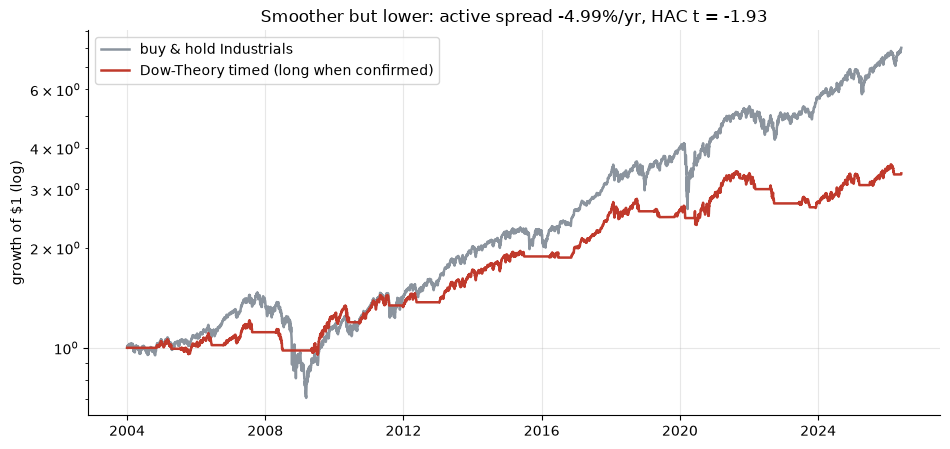

active spread -4.99%/yr   HAC t = -1.935  (negative => timing LOSES to buy-and-hold)


In [2]:
if HAVE_REAL:
    reg = st.latched_regime(DF)
    bt = st.backtest(DF, reg, cost_bps=2.0)
    eq_bh = (1+bt['r_indu']).cumprod(); eq_st = (1+bt['r_strat_net']).cumprod()
    s = st.summarize(DF, latched=True, cost_bps=2.0)
    at = s['active_t']; am = s['active_mean_ann']*100
else:
    idx = pd.bdate_range('2004-01-02', periods=R['n_days'])
    eq_bh = pd.Series(np.linspace(0,1,R['n_days']), index=idx).pipe(lambda x: (1+R['bh_cagr']/100/252)**np.arange(R['n_days']))
    eq_st = (1+R['latched'][1]/100/252)**np.arange(R['n_days'])
    eq_bh = pd.Series(eq_bh, index=idx); eq_st = pd.Series(eq_st, index=idx)
    at, am = R['latched'][5], R['latched'][4]
fig, ax = plt.subplots(figsize=(9.6, 4.6))
ax.plot(eq_bh.index, eq_bh.values, c=GREY, lw=1.8, label='buy & hold Industrials')
ax.plot(eq_st.index, eq_st.values, c=RED, lw=1.8, label='Dow-Theory timed (long when confirmed)')
ax.set_yscale('log'); ax.set_ylabel('growth of $1 (log)'); ax.legend()
ax.set_title(f'Smoother but lower: active spread {am:+.2f}%/yr, HAC t = {at:.2f}')
plt.tight_layout(); plt.show()
print(f'active spread {am:+.2f}%/yr   HAC t = {at:.3f}  (negative => timing LOSES to buy-and-hold)')

> 💡 In plain words: the red curve rides lower the whole way and ends below grey. The active spread is **-4.99%/yr** at **HAC t = -1.94** — a *significantly negative* timing contribution. Dow-Theory timing doesn't just fail to help; on this tape it actively costs you.

### 4b · The content test — does the flag predict at all?

Strip the cash-drag. Compare the Industrials' **next-day** return on confirmed vs non-confirmed days, for both the latched regime and the raw instantaneous flag. A real signal would show confirmed ≫ non-confirmed with *t* ≥ 2.

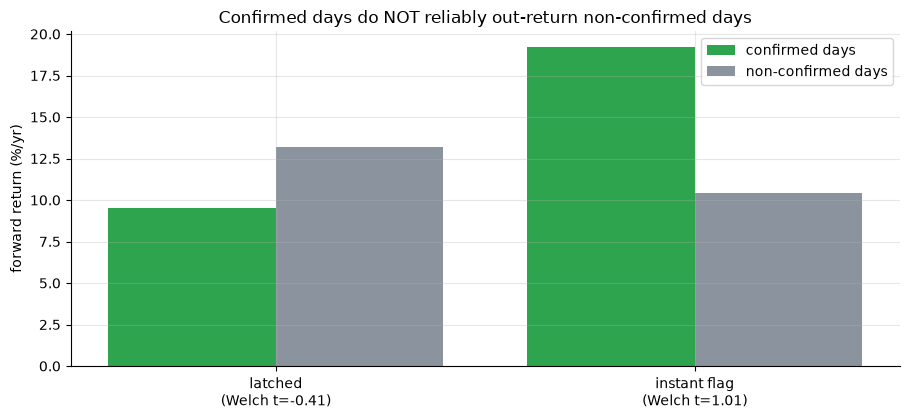

latched: confirmed +9.51%/yr vs non +13.17%/yr  Welch t=-0.41
instant: confirmed +19.20%/yr vs non +10.40%/yr  Welch t=1.01


In [3]:
if HAVE_REAL:
    cl = st.confirmed_vs_not(DF, latched=True)
    ci = st.confirmed_vs_not(DF, latched=False)
    L = (cl['mean_on_ann']*100, cl['mean_off_ann']*100, cl['welch_t'])
    I = (ci['mean_on_ann']*100, ci['mean_off_ann']*100, ci['welch_t'])
else:
    L = (R['content_latched'][0], R['content_latched'][1], R['content_latched'][3])
    I = (R['content_instant'][0], R['content_instant'][1], R['content_instant'][3])
fig, ax = plt.subplots(figsize=(9.2, 4.3))
x = np.arange(2)
ax.bar(x-.2, [L[0], I[0]], .4, color=GREEN, label='confirmed days')
ax.bar(x+.2, [L[1], I[1]], .4, color=GREY, label='non-confirmed days')
ax.set_xticks(x); ax.set_xticklabels([f'latched\n(Welch t={L[2]:.2f})', f'instant flag\n(Welch t={I[2]:.2f})'])
ax.set_ylabel('forward return (%/yr)'); ax.axhline(0,c='k',lw=.7)
ax.set_title('Confirmed days do NOT reliably out-return non-confirmed days'); ax.legend()
plt.tight_layout(); plt.show()
print(f'latched: confirmed {L[0]:+.2f}%/yr vs non {L[1]:+.2f}%/yr  Welch t={L[2]:.2f}')
print(f'instant: confirmed {I[0]:+.2f}%/yr vs non {I[1]:+.2f}%/yr  Welch t={I[2]:.2f}')

> 💡 In plain words: on the **latched** regime, confirmed days actually return *less* (**+9.51%/yr** vs **+13.17%/yr**, Welch t = -0.41). The instantaneous flag is positive (**+8.80%/yr**) but **t = 1.01**, under the bar — and it fires only 5.5% of days. No reliable forward content either way.

### 4c · The placebo — confirmation, or just cash?

The decisive honesty check. Build 2,000 **random** regimes matched to the real regime's on-fraction and average run length (a two-state Markov chain), run the identical backtest, and see where the real rule lands in the distribution of random Sharpes.

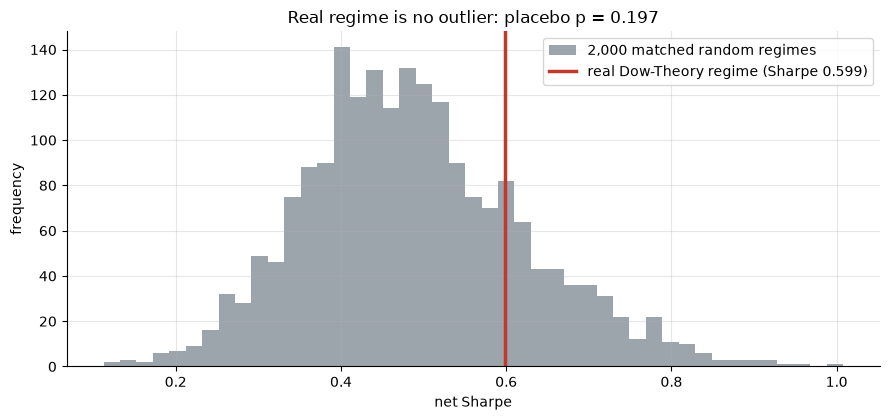

observed Sharpe 0.599  placebo mean 0.489  p(random>=real) = 0.197


In [4]:
if HAVE_REAL:
    reg = st.latched_regime(DF)
    pl = st.placebo_pvalue(DF, reg, n_draws=2000, cost_bps=2.0)
    obs, draws, p = pl['obs_sharpe'], pl['draws'], pl['p_value']
else:
    obs, p = R['placebo'][0], R['placebo'][2]
    rng = np.random.default_rng(444); draws = rng.normal(R['placebo'][1], 0.12, 2000)
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(draws, bins=45, color=GREY, alpha=.85, label='2,000 matched random regimes')
ax.axvline(obs, c=RED, lw=2.5, label=f'real Dow-Theory regime (Sharpe {obs:.3f})')
ax.set_xlabel('net Sharpe'); ax.set_ylabel('frequency')
ax.set_title(f'Real regime is no outlier: placebo p = {p:.3f}'); ax.legend()
plt.tight_layout(); plt.show()
print(f'observed Sharpe {obs:.3f}  placebo mean {np.nanmean(draws):.3f}  p(random>=real) = {p:.3f}')

> 💡 In plain words: the real regime sits at **p = 0.197** — a random cash rule with the same persistence beats it about a fifth of the time. The modest lift over the *average* random rule comes from *how often* it held cash (which dodged 2008/2020 in this sample), **not** from the Industrials/Transports agreement. H₃ rejected.

### 4d · Robustness — negative at every knob

The active HAC *t* across costs and across trailing-high windows, plus the independent **34-year** ^DJI/^DJT price-only check. If there were a fragile edge, *some* knob would lift the *t* above 2. None does (in the right direction).

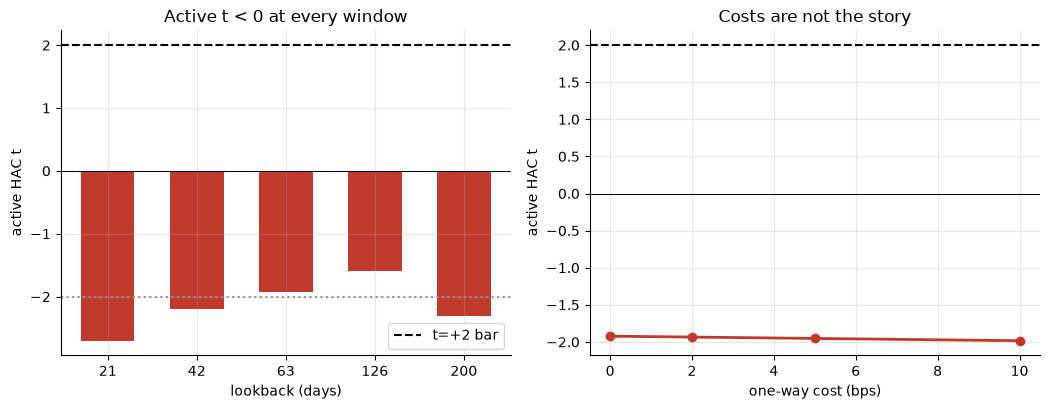

lookback active t: [-2.7, -2.19, -1.93, -1.59, -2.31]
long index ^DJI/^DJT 1992->2026: active t -1.969  content Welch t -0.189


In [5]:
if HAVE_REAL:
    lbs = [21,42,63,126,200]
    lt = [st.summarize(DF, lookback=lb, latched=True, cost_bps=2.0)['active_t'] for lb in lbs]
    cs = [0.0,2.0,5.0,10.0]
    ct = [st.summarize(DF, latched=True, cost_bps=c)['active_t'] for c in cs]
else:
    lbs=[r[0] for r in R['lookbacks']]; lt=[r[3] for r in R['lookbacks']]
    cs=[r[0] for r in R['costs']]; ct=[r[2] for r in R['costs']]
fig,(a1,a2)=plt.subplots(1,2,figsize=(10.6,4.2))
a1.bar([str(l) for l in lbs], lt, color=RED, width=.6)
a1.axhline(2, ls='--', c='k', label='t=+2 bar'); a1.axhline(-2, ls=':', c=GREY)
a1.axhline(0,c='k',lw=.7); a1.set_xlabel('lookback (days)'); a1.set_ylabel('active HAC t')
a1.set_title('Active t < 0 at every window'); a1.legend()
a2.plot(cs, ct, 'o-', c=RED, lw=2); a2.axhline(0,c='k',lw=.7); a2.axhline(2,ls='--',c='k')
a2.set_xlabel('one-way cost (bps)'); a2.set_ylabel('active HAC t'); a2.set_title('Costs are not the story')
plt.tight_layout(); plt.show()
print('lookback active t:', [round(v,2) for v in lt])
print('long index ^DJI/^DJT 1992->2026: active t', R['idx'][3], ' content Welch t', R['idx'][5])

> 💡 In plain words: active *t* is **negative for every lookback** (21→200) and barely moves with cost — there was no gross edge to charge against. And on **34 years** of raw index history the result holds: active **t = -1.97**, content spread **-1.28%/yr** (Welch t = -0.19). Robustly nothing.

### 4e · Faithful-engine & power control — we know the truth here

On a deterministic two-series panel where we **plant** a confirmation edge (the Industrials' return is genuinely boosted on confirmed days), the content test must recover it; with **zero** planted edge it must stay near *t* = 0. Both hold — so the real-tape null is a real null.

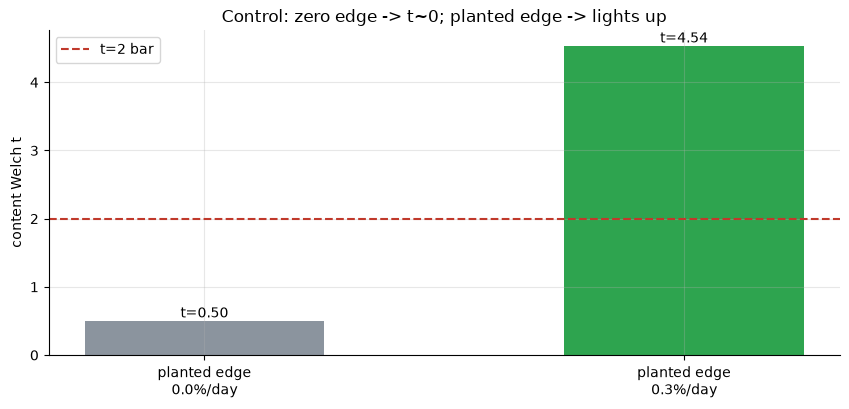

planted +0.0%/day: content spread +10.65%/yr  Welch t=0.50
planted +0.3%/day: content spread +91.55%/yr  Welch t=4.54


In [6]:
res = []
for edge in (0.0, 0.003):
    px, truth = data.synthetic_panel(edge=edge, seed=444, n_days=8000)
    c = st.confirmed_vs_not(px, latched=False)
    res.append((edge, c['spread_ann']*100, c['welch_t']))
fig, ax = plt.subplots(figsize=(8.6, 4.2))
labels = [f'planted edge\n{e*100:.1f}%/day' for e,_,_ in res]
tvals = [r[2] for r in res]
ax.bar(labels, tvals, color=[GREY, GREEN], width=.5)
ax.axhline(2, ls='--', c=RED, label='t=2 bar')
for i,t in enumerate(tvals): ax.annotate(f't={t:.2f}',(i,t),ha='center',va='bottom')
ax.set_ylabel('content Welch t'); ax.set_title('Control: zero edge -> t~0; planted edge -> lights up'); ax.legend()
plt.tight_layout(); plt.show()
for e,sp,t in res: print(f'planted {e*100:+.1f}%/day: content spread {sp:+.2f}%/yr  Welch t={t:.2f}')

> 💡 In plain words: zero planted edge → **t = 0.50** (no false positive); a big planted edge → **t = 4.54**. The harness *can* find a confirmation edge when one exists — it just doesn't find one on the real Industrials/Transports tape. The negative real-tape result is genuine, not a broken detector.

## 5 · The verdict

- **Signal `NONE`** — the active spread vs buy-and-hold is **negative** (HAC **t = -1.94** latched, **-3.14** flag); the content test is **-3.67%/yr (t = -0.41)** latched and **+8.80%/yr (t = 1.01)** on the flag — never clears **t ≥ 2** the believers' way, and the sign holds over 34 years of index history. Indistinguishable from noise (if anything, the wrong sign).
- **Tradability `MIRAGE`** — matches buy-and-hold's Sharpe (**0.60** vs **0.61**) only by giving up **4.2 pts of CAGR** for a smaller drawdown — pure de-risking from 62% time-in-market, available from any cash rule. No residual edge to scale.
- **I/T confirmation? `BUSTED`** — a random regime matched on on-fraction + persistence beats the real one (**p = 0.197**). The two averages agreeing carries no information beyond being in cash part of the time.

## 6 · Could you trade it? — the de-risking dial

The operational truth in one frame: the return/drawdown trade-off. Dow-Theory timing is a **de-risking dial**, not an alpha source — and a static cash/equity mix or a balanced fund gives you the same dial without the narrative or the turnover.

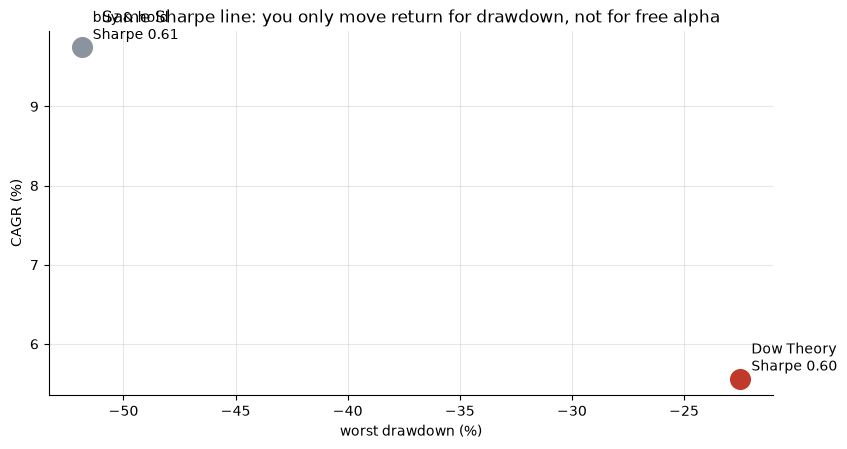

Both points sit on essentially the same Sharpe ray from the origin -> no alpha, just leverage/cash.


In [7]:
if HAVE_REAL:
    s = st.summarize(DF, latched=True, cost_bps=2.0)
    pts = {'buy & hold': (s['bh_mdd']*100, s['bh_cagr']*100, s['bh_sharpe']),
           'Dow Theory': (s['st_mdd']*100, s['st_cagr']*100, s['st_sharpe'])}
else:
    pts = {'buy & hold': (R['bh_mdd'], R['bh_cagr'], R['bh_sharpe']),
           'Dow Theory': (R['latched'][3], R['latched'][1], R['latched'][2])}
fig, ax = plt.subplots(figsize=(8.6, 4.6))
for (lab,(d,c,sh)),col in zip(pts.items(),[GREY,RED]):
    ax.scatter(d, c, s=200, color=col, zorder=3)
    ax.annotate(f'{lab}\nSharpe {sh:.2f}',(d,c),textcoords='offset points',xytext=(8,6))
ax.set_xlabel('worst drawdown (%)'); ax.set_ylabel('CAGR (%)')
ax.set_title('Same Sharpe line: you only move return for drawdown, not for free alpha')
plt.tight_layout(); plt.show()
print('Both points sit on essentially the same Sharpe ray from the origin -> no alpha, just leverage/cash.')

> 💡 In plain words: the two points lie on roughly the same Sharpe ray. Moving along that ray (more cash → less return, less drawdown) is what *any* de-risking does. The confirmation adds nothing you couldn't get by holding less equity — hence **MIRAGE**, not a tradable edge.

## 7 · Going further

- **The historical record agrees.** Cowles (1933) scored Hamilton's published Dow-Theory calls and found them below buy-and-hold; Brown, Goetzmann & Kumar (1998) re-ran him and found the *only* benefit was drawdown reduction from cash — exactly this. We reproduced a 90-year-old verdict mechanically.
- **The subjective version.** Discretionary Dow Theorists read "significant" highs and secondary reactions by eye. The burden is theirs: show the discretionary calls clearing *t* = 2 against this matched-persistence placebo.
- **As a filter, not a switch.** Maybe the confirmation adds value *conditioning* a momentum/breadth book rather than as a binary on/off. The engine is in [`dow_theory/`](../dow_theory).

*The reproducible core is offline and deterministic; the confirmation is the both-averages trailing-high/low rule. Methods and sources: [`docs/references.md`](../docs/references.md); frozen numbers: [`docs/results.md`](../docs/results.md).*